In [1]:
import pandas as pd
from dotenv import dotenv_values
import requests
from io import BytesIO
import unicodedata
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu


#ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Mostrar todas la columnas de los DataFrame
pd.set_option("display.max_columns", None)  # mostrar todas las columnas

In [3]:
import sys
import os
sys.path.insert(0, os.path.abspath("../.."))
from src.pipeline import run_etl
from src.pipeline import DOMINIOS, DC_ORDER, DC_LABELS
DC_PALETTE = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c"}


In [4]:
df_tabla_0_imp, df_tabla_1_imp,df_mean, df_median = run_etl("../../.env")

Descargando datos desde GitHub...
Hojas cargadas: 125
Tabla 0 (escolaridad baja) : 36
Tabla 1 (escolaridad alta) : 81
No determinadas            : 8
df_tabla_0 crudo : (36, 32)
df_tabla_1 crudo : (81, 29)

 Imputando nulos...
--- Perfil nulos Tabla 0 ---
                                         nulos  %_nulos dtype  n_unicos
fluidez_verbal_semantica                    23    63.89   str         4
matrices                                    12    33.33   str         4
imagenes_sobrepuestas                       11    30.56   str         3
stroop_interferencia                         9    25.00   str         4
material_verbal_complejo                     6    16.67   str         3
denominacion                                 5    13.89   str         1
stroop_palabra                               4    11.11   str         4
stroop_color                                 4    11.11   str         4
atencion_sostenida_visual                    4    11.11   str         4
evocacion_diferida       

In [5]:
df_mean_imp = df_mean.copy().fillna(df_mean.median())

In [7]:
df_mean_imp.describe().T

,count,mean,std,min,25%,50%,75%,max
nivel_estudio,117.0,0.692308,0.463524,0.000000,0.000000,1.000000,1.00,1.000000
dc,117.0,1.042735,0.711884,0.000000,1.000000,1.000000,2.00,2.000000
age_num,117.0,70.743590,9.698164,51.000000,65.000000,71.000000,77.00,96.000000
n_orientacion,117.0,3.000000,0.000000,3.000000,3.000000,3.000000,3.00,3.000000
orientacion,117.0,2.849003,0.935154,1.000000,2.333333,3.000000,4.00,4.000000
n_atencion,117.0,3.307692,0.463524,3.000000,3.000000,3.000000,4.00,4.000000
atencion,117.0,2.817664,0.378722,1.666667,2.666667,3.000000,3.00,3.666667
n_lenguaje,117.0,3.726496,0.447675,3.000000,3.000000,4.000000,4.00,4.000000
lenguaje,117.0,3.341168,0.547874,2.000000,3.000000,3.500000,3.75,4.000000
n_memoria_verbal,117.0,5.042735,0.770056,3.000000,4.000000,5.000000,6.00,6.000000


In [9]:
pd.crosstab(df_mean_imp.fillna(df_mean_imp.median())['dc'], df_mean_imp.fillna(df_mean_imp.median())["gnosias"])

gnosias,2.0,2.5,3.0,3.5,4.0
dc,,,,,
0,0,0,4,10,13
1,5,1,6,6,40
2,13,0,2,1,16


In [10]:
DOMINIOS_COGNITIVOS = list(DOMINIOS.keys())

Kruskal-Wallis: diferencias entre grupos clínicos

Dominio                     H      p-value       ε²       Efecto
----------------------------------------------------------------------
orientacion            42.835   0.00000000    0.358       Grande
    count      mean       std       min       25%       50%       75%  max
dc                                                                        
0    27.0  3.506173  0.542000  2.333333  3.000000  4.000000  4.000000  4.0
1    58.0  3.000000  0.806890  1.000000  2.666667  3.000000  4.000000  4.0
2    32.0  2.020833  0.837891  1.000000  1.000000  2.333333  2.333333  4.0
dc
0    27
1    58
2    32
Name: count, dtype: int64

  Dunn Post Hoc (Holm)

        0       1    2
0  1.0000  0.0115  0.0
1  0.0115  1.0000  0.0
2  0.0000  0.0000  1.0

atencion               34.231   0.00000004    0.283       Grande
    count      mean       std       min       25%       50%   75%       max
dc                                                           

,Dominio,H,p,epsilon2,efecto
7,ejecutivas,54.8802,0.0000,0.4639,Grande
4,memoria_visual,49.7299,0.0000,0.4187,Grande
0,orientacion,42.8352,0.0000,0.3582,Grande
6,praxis,38.2364,0.0000,0.3179,Grande
1,atencion,34.2307,0.0000,0.2827,Grande
3,memoria_verbal,19.7480,0.0001,0.1557,Moderado
2,lenguaje,17.3104,0.0002,0.1343,Moderado
5,gnosias,6.5581,0.0377,0.0400,Pequeño


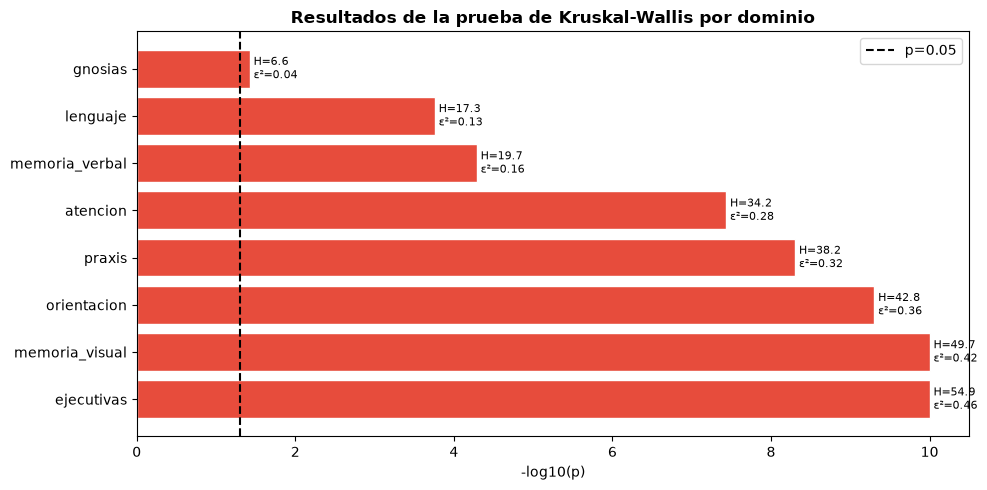

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal
import scikit_posthocs as sp

print("Kruskal-Wallis: diferencias entre grupos clínicos\n")
print(f"{'Dominio':<20} {'H':>8} {'p-value':>12} {'ε²':>8} {'Efecto':>12}")
print("-"*70)

kw_rows = []

#Rellenar los valores nulos con la mediana de cada dominio para poder realizar la prueba de Kruskal-Wallis

for dom in DOMINIOS:
    # Grupos
    grupos = [
        df_mean_imp[df_mean_imp["dc"] == g][dom].dropna()
        for g in DC_ORDER
    ]

    grupos_ok = [g for g in grupos if len(g) >= 2]

    if len(grupos_ok) < 2:
        continue

    # Kruskal
    H, p = kruskal(*grupos_ok)

    n = sum(len(g) for g in grupos_ok)
    k = len(grupos_ok)

    # Tamaño del efecto
    epsilon2 = (H - k + 1) / (n - k)

    # Interpretación
    if epsilon2 < 0.01:
        efecto = "Despreciable"
    elif epsilon2 < 0.08:
        efecto = "Pequeño"
    elif epsilon2 < 0.26:
        efecto = "Moderado"
    else:
        efecto = "Grande"

    kw_rows.append({
        "Dominio": dom,
        "H": H,
        "p": p,
        "epsilon2": epsilon2,
        "efecto": efecto
    })

    print(f"{dom:<20} {H:8.3f} {p:12.8f} {epsilon2:8.3f} {efecto:>12}")

    # -------------------------
    # Dunn Post Hoc
    # -------------------------
    print(df_mean_imp.groupby("dc")[dom].describe())
    print(df_mean_imp["dc"].value_counts().sort_index())
    if p < 0.05:

        print("\n  Dunn Post Hoc (Holm)\n")

        dunn = sp.posthoc_dunn(
            df_mean_imp,
            val_col=dom,
            group_col="dc",
            p_adjust="holm"
        )

        print(dunn.round(4))
        print()

# -------------------------
# Tabla resumen
# -------------------------

df_kw = pd.DataFrame(kw_rows).sort_values("p")

print("\nResumen\n")
display(df_kw.round(4))

# -------------------------
# Gráfico
# -------------------------

n_kw = len(df_kw)

fig, ax = plt.subplots(figsize=(10,5))

colors = [
    "#e74c3c" if p < 0.05 else "#95a5a6"
    for p in df_kw["p"]
]

ax.barh(
    df_kw["Dominio"],
    -np.log10(df_kw["p"].clip(lower=1e-10)),
    color=colors,
    edgecolor="white"
)

ax.axvline(
    -np.log10(0.05),
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="p=0.05"
)

ax.set_xlabel("-log10(p)")
ax.set_title("Resultados de la prueba de Kruskal-Wallis por dominio", fontweight="bold")
ax.legend()

for i, row in enumerate(df_kw.itertuples()):

    ax.text(
        -np.log10(max(row.p,1e-10))+0.05,
        i,
        f"H={row.H:.1f}\nε²={row.epsilon2:.2f}",
        va="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [9]:
DC_LABELS

{0: 'Control', 1: 'DCL', 2: 'Demencia'}